In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 226.8 KB


In [3]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing Values:")
print(missing_values)

Missing Values:
CouponCode    309
dtype: int64


In [4]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,1200,1200,ORD200000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,671,2023-08-20,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1200,1189,C98474,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.0,NaN,NaN,NaN,2.945833,1.407557,1.0,2.0,3.0,4.0,5.0
UnitPrice,1200.0,NaN,NaN,NaN,356.41275,197.177146,11.39,186.0625,364.21,521.57,699.93
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK37947903,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
categorical_columns = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Product ---
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

--- OrderStatus ---
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

--- CouponCode ---
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

--- ReferralSource ---
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [7]:
numerical_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

df[numerical_columns].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


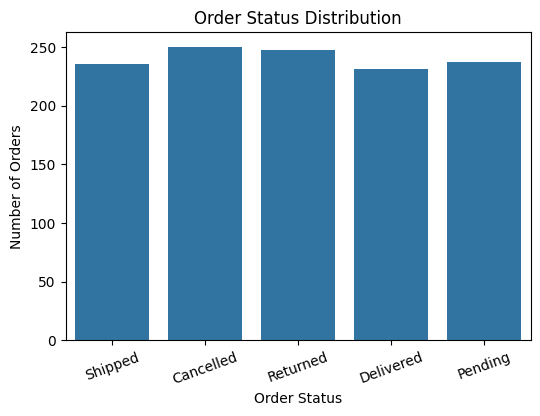

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(x="OrderStatus", data=df)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

In [9]:
df["OrderStatus"].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

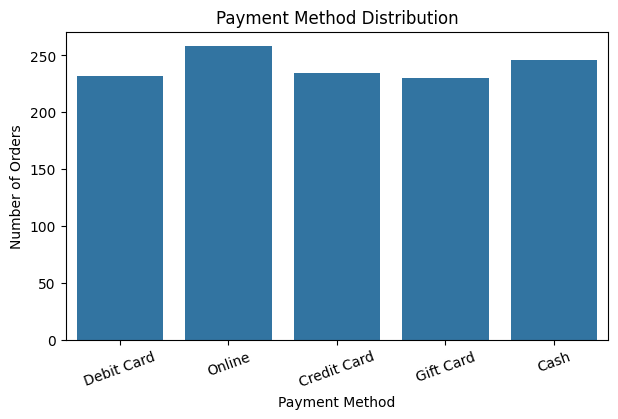

In [10]:
plt.figure(figsize=(7, 4))

sns.countplot(x="PaymentMethod", data=df)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

In [11]:
df["PaymentMethod"].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

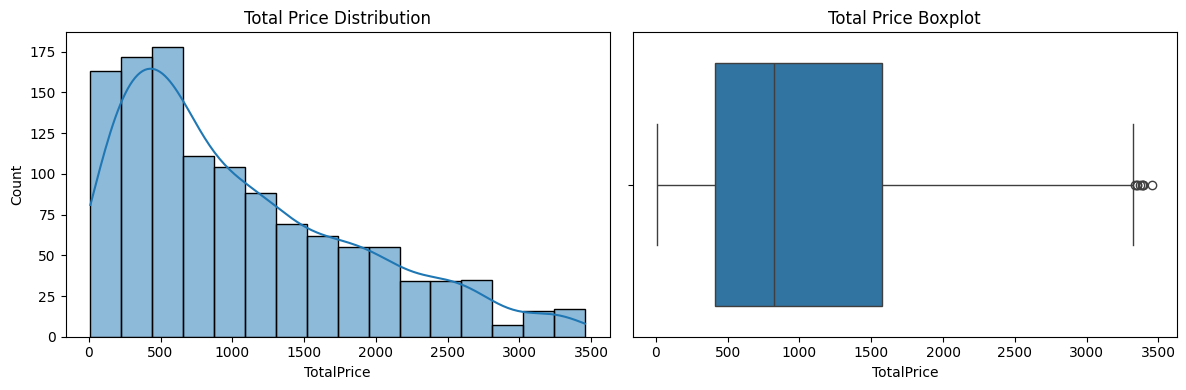

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["TotalPrice"], kde=True, ax=axes[0])
axes[0].set_title("Total Price Distribution")

sns.boxplot(x=df["TotalPrice"], ax=axes[1])
axes[1].set_title("Total Price Boxplot")

plt.tight_layout()
plt.show()

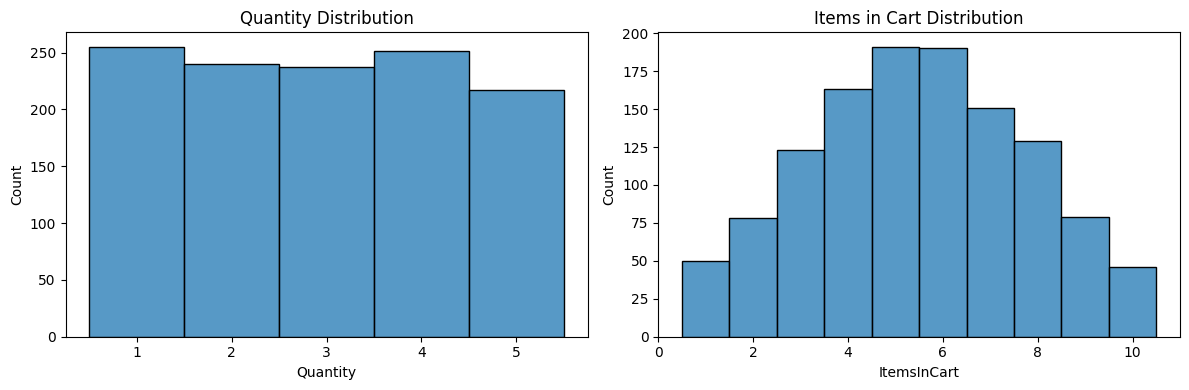

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Quantity"], discrete=True, ax=axes[0])
axes[0].set_title("Quantity Distribution")

sns.histplot(df["ItemsInCart"], discrete=True, ax=axes[1])
axes[1].set_title("Items in Cart Distribution")

plt.tight_layout()
plt.show()

In [14]:
# High-value transaction indicator
q1 = df["TotalPrice"].quantile(0.25)
q3 = df["TotalPrice"].quantile(0.75)

iqr = q3 - q1
high_value_threshold = q3 + 1.5 * iqr

df["HighValue"] = (
    df["TotalPrice"] > high_value_threshold
).astype(int)


# Large quantity indicator
df["LargeQuantity"] = (
    df["Quantity"] >= df["Quantity"].quantile(0.90)
).astype(int)


# Large cart indicator
df["LargeCart"] = (
    df["ItemsInCart"] >= df["ItemsInCart"].quantile(0.90)
).astype(int)


# Missing coupon indicator
df["NoCoupon"] = (
    df["CouponCode"].isna()
).astype(int)

In [15]:
df["RiskScore"] = (
    df["HighValue"]
    + df["LargeQuantity"]
    + df["LargeCart"]
    + df["NoCoupon"]
)

In [16]:
df["RiskScore"].value_counts().sort_index()

RiskScore
0    702
1    365
2    105
3     28
Name: count, dtype: int64

In [17]:
df["FraudRisk"] = (
    df["RiskScore"] >= 3
).astype(int)

In [18]:
print(df["FraudRisk"].value_counts())

print("\nClass Percentage:")
print(
    df["FraudRisk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

FraudRisk
0    1172
1      28
Name: count, dtype: int64

Class Percentage:
FraudRisk
0    97.67
1     2.33
Name: proportion, dtype: float64


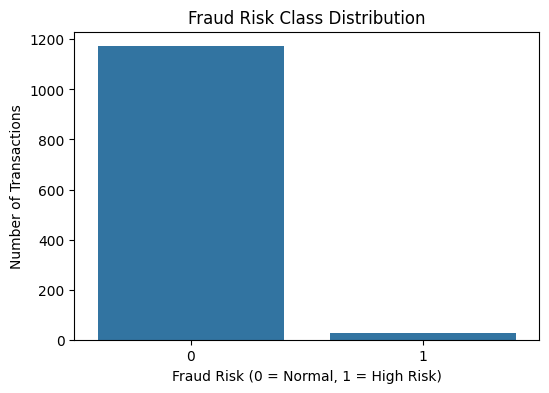

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="FraudRisk",
    data=df
)

plt.title("Fraud Risk Class Distribution")
plt.xlabel("Fraud Risk (0 = Normal, 1 = High Risk)")
plt.ylabel("Number of Transactions")

plt.show()

In [20]:
df["RiskScore"].value_counts().sort_index()

RiskScore
0    702
1    365
2    105
3     28
Name: count, dtype: int64

In [21]:
df["FraudRisk"].value_counts()

FraudRisk
0    1172
1      28
Name: count, dtype: int64

In [22]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract useful temporal features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [23]:
print("Target distribution:")
print(df["FraudRisk"].value_counts())

print("\nTarget percentage:")
print(
    df["FraudRisk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
FraudRisk
0    1172
1      28
Name: count, dtype: int64

Target percentage:
FraudRisk
0    97.67
1     2.33
Name: proportion, dtype: float64


In [24]:
columns_to_drop = [
    "FraudRisk",
    "RiskScore",
    "HighValue",
    "LargeQuantity",
    "LargeCart",
    "NoCoupon",
    "OrderID",
    "CustomerID",
    "Date",
    "TrackingNumber",
    "ShippingAddress"
]

X = df.drop(columns=columns_to_drop)

y = df["FraudRisk"]

In [25]:
print("Feature shape:", X.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (1200, 13)

Features:
['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'OrderStatus', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year', 'Month', 'DayOfWeek', 'IsWeekend']


In [26]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

Numerical features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'IsWeekend']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19452\2339720342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 960
Testing samples : 240


In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [30]:
numeric_transformer_lr = ImbPipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = ImbPipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [32]:
from sklearn.pipeline import Pipeline

preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_lr,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [33]:
logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [34]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['Product','Quantity','UnitPrice',...,'Month','DayOfWeek','IsWeekend']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [35]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [36]:
random_forest_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor_rf),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [37]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['Product','Quantity','UnitPrice',...,'Month','DayOfWeek','IsWeekend']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [38]:
print("Original training distribution:")
print(y_train.value_counts())

Original training distribution:
FraudRisk
0    938
1     22
Name: count, dtype: int64


In [39]:
X_train_prepared = preprocessor_rf.fit_transform(X_train)

X_train_smote, y_train_smote = SMOTE(
    random_state=42
).fit_resample(
    X_train_prepared,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


After SMOTE:
FraudRisk
0    938
1    938
Name: count, dtype: int64


In [40]:
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = random_forest_pipeline.predict(X_test)
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [41]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression
-------------------
Precision : 0.7500
Recall    : 1.0000
ROC-AUC   : 0.9986

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       234
           1       0.75      1.00      0.86         6

    accuracy                           0.99       240
   macro avg       0.88      1.00      0.93       240
weighted avg       0.99      0.99      0.99       240



In [42]:
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest
-------------
Precision : 1.0000
Recall    : 0.5000
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



In [43]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

model_results

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.75,1.0,0.998575
1,Random Forest,1.00,0.5,1.000000


In [44]:
model_results.round(4)

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.75,1.0,0.9986
1,Random Forest,1.00,0.5,1.0000


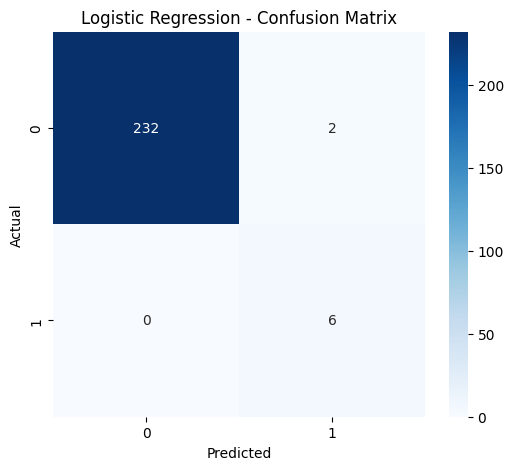

In [45]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

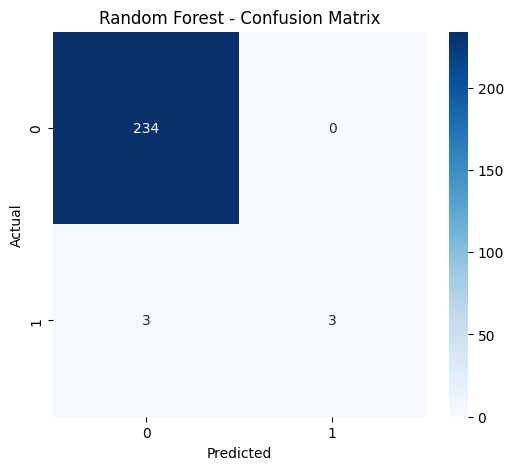

In [46]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

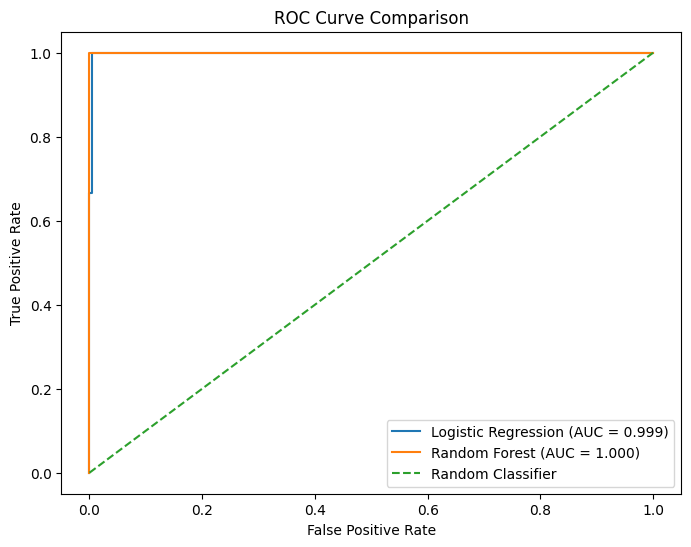

In [47]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [48]:
model_results.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [49]:
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "smote__sampling_strategy": [0.5, 1.0],
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear"],
    "classifier__class_weight": [None, "balanced"]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

logistic_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__solver': ['liblinear'], 'smote__sampling_strategy': [0.5, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metri

In [50]:
print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(logistic_grid.best_score_, 4))

Best Logistic Regression Parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear', 'smote__sampling_strategy': 0.5}

Best Cross-Validation ROC-AUC:
0.9927


In [51]:
random_forest_param_grid = {
    "smote__sampling_strategy": [0.5, 1.0],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

random_forest_grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multip

In [52]:
print("Best Random Forest Parameters:")
print(random_forest_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(random_forest_grid.best_score_, 4))

Best Random Forest Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100, 'smote__sampling_strategy': 1.0}

Best Cross-Validation ROC-AUC:
0.9982


In [53]:
best_lr = logistic_grid.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

precision_lr_tuned = precision_score(
    y_test,
    y_pred_lr_tuned,
    zero_division=0
)

recall_lr_tuned = recall_score(
    y_test,
    y_pred_lr_tuned,
    zero_division=0
)

roc_auc_lr_tuned = roc_auc_score(
    y_test,
    y_prob_lr_tuned
)

print("Tuned Logistic Regression")
print("-------------------------")
print(f"Precision : {precision_lr_tuned:.4f}")
print(f"Recall    : {recall_lr_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_lr_tuned:.4f}")

Tuned Logistic Regression
-------------------------
Precision : 0.2000
Recall    : 1.0000
ROC-AUC   : 1.0000


In [54]:
best_rf = random_forest_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

precision_rf_tuned = precision_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

recall_rf_tuned = recall_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

roc_auc_rf_tuned = roc_auc_score(
    y_test,
    y_prob_rf_tuned
)

print("Tuned Random Forest")
print("-------------------")
print(f"Precision : {precision_rf_tuned:.4f}")
print(f"Recall    : {recall_rf_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_rf_tuned:.4f}")

Tuned Random Forest
-------------------
Precision : 1.0000
Recall    : 0.5000
ROC-AUC   : 1.0000


In [55]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_lr_tuned,
        precision_rf,
        precision_rf_tuned
    ],
    "Recall": [
        recall_lr,
        recall_lr_tuned,
        recall_rf,
        recall_rf_tuned
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_lr_tuned,
        roc_auc_rf,
        roc_auc_rf_tuned
    ]
})

final_results.round(4)

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.75,1.0,0.9986
1,Tuned Logistic Regression,0.20,1.0,1.0000
2,Random Forest,1.00,0.5,1.0000
3,Tuned Random Forest,1.00,0.5,1.0000


In [56]:
final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

In [57]:
final_results.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)

,Model,Precision,Recall,ROC-AUC
1,Tuned Logistic Regression,0.20,1.0,1.0000
2,Random Forest,1.00,0.5,1.0000
3,Tuned Random Forest,1.00,0.5,1.0000
0,Logistic Regression,0.75,1.0,0.9986


In [58]:
print("Best Logistic Regression:")
print(logistic_grid.best_params_)

print("\nBest Random Forest:")
print(random_forest_grid.best_params_)

Best Logistic Regression:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear', 'smote__sampling_strategy': 0.5}

Best Random Forest:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100, 'smote__sampling_strategy': 1.0}


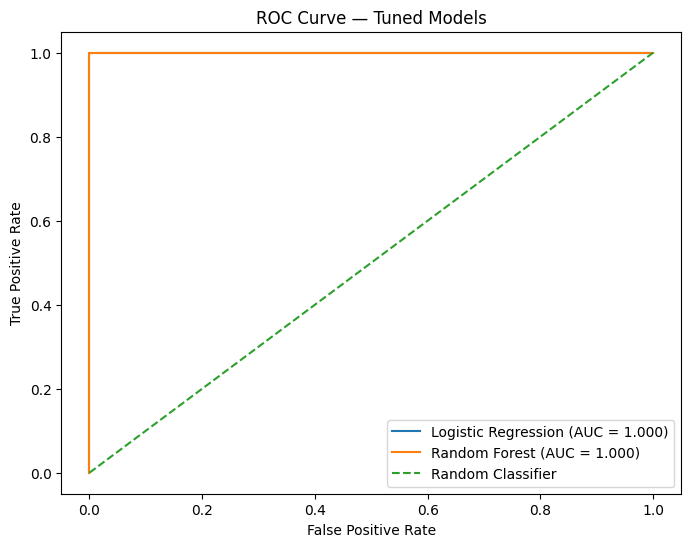

In [59]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr_tuned
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf_tuned
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr_tuned:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf_tuned:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Models")
plt.legend()

plt.show()

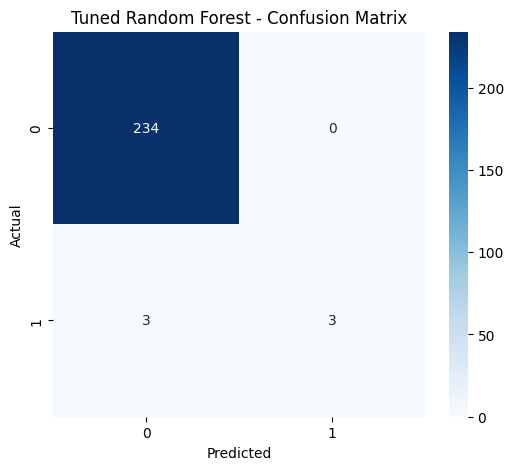

In [60]:
cm = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

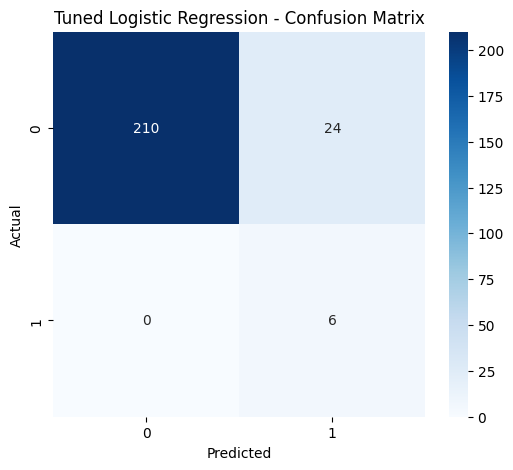

In [61]:
cm = confusion_matrix(
    y_test,
    y_pred_lr_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
rf_preprocessor = best_rf.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

rf_model = best_rf.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__Quantity,0.258296
2,num__ItemsInCart,0.206909
25,cat__CouponCode_nan,0.174579
27,cat__ReferralSource_Facebook,0.067143
3,num__TotalPrice,0.041648
12,cat__PaymentMethod_Cash,0.033242
11,cat__Product_Tablet,0.030218
22,cat__CouponCode_FREESHIP,0.026403
23,cat__CouponCode_SAVE10,0.021758
24,cat__CouponCode_WINTER15,0.016010


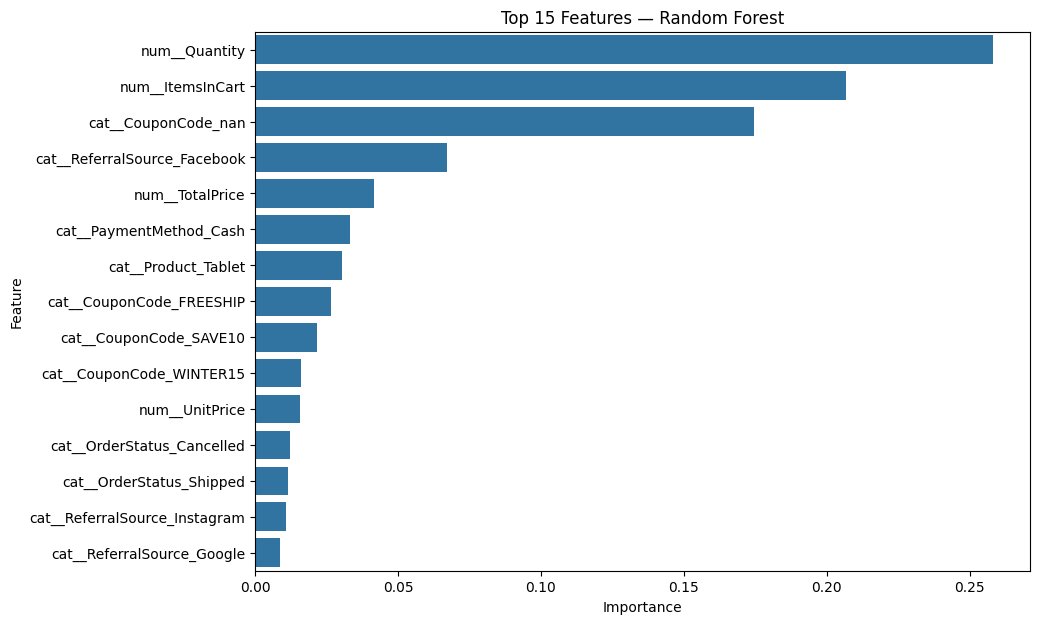

In [63]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [64]:
feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

In [65]:
plt.savefig(
    "roc_curve_tuned_models.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>